# 04. File Memory, AGENTS.md, and Workspace Context

Этот ноутбук продолжает `01-03`, но делает шаг в другую сторону.

Там основной вопрос был таким: **как агент получает доступ к знаниям**.
Здесь вопрос другой: **как агент работает в конкретном workspace и не начинает каждый запуск с нуля**.

Фокус этого ноутбука:
- `AGENTS.md` / `CLAUDE.md` как instruction layer;
- файловая working memory как persistent operational context;
- минимальный `LangGraph`, который явно загружает этот контекст перед LLM-вызовом.


## Что должно получиться к концу ноутбука

К концу ноутбука студент должен уметь:
- объяснить разницу между `knowledge`, `instructions` и `working memory`;
- объяснить, почему `RAG` не заменяет `AGENTS.md` и memory files;
- собрать минимальный граф `load_context -> inspect_workspace -> agent -> maybe_write_memory`;
- показать, как persistent context меняет поведение агента между запусками;
- назвать основные failure modes: stale instructions, stale memory, noise, conflicting notes.


## Outline

1. Почему `RAG` недостаточно для workspace-агента
2. Три слоя внешнего контекста
3. Demo workspace: `AGENTS.md` и memory files
4. Минимальный `LangGraph`
5. Первый и второй запуск агента
6. Почему это не то же самое, что `RAG`
7. Failure modes и упражнения


## Почему `RAG` недостаточно

`RAG` и `GraphRAG` отвечают на вопрос: **что известно в корпусе документов**.

Но workspace-агенту обычно нужны еще два вида внешнего контекста:
- **instructions**: как именно работать в этом проекте;
- **working memory**: что уже было выяснено в прошлых запусках.

В реальных agent runtimes instruction files вроде `AGENTS.md` или `CLAUDE.md` часто подключаются автоматически.
В этом ноутбуке мы делаем этот шаг **явным**, чтобы было видно, как контекст попадает в граф.


## Три слоя внешнего контекста

| Layer | Пример | Главный вопрос |
|---|---|---|
| Knowledge | PDF, Chroma, BM25, graph | Что известно по теме? |
| Instructions | `AGENTS.md`, `CLAUDE.md` | Как здесь нужно работать? |
| Working memory | `task_notes.md`, `known_pitfalls.md` | Что уже выяснили раньше? |

Важно: в этом ноутбуке мы **не дублируем knowledge base** в памяти. Мы храним только то, что помогает следующему запуску агента работать лучше в этом workspace.


In [1]:
from __future__ import annotations

import os
from pathlib import Path
from typing import TypedDict

from dotenv import load_dotenv
from langchain_gigachat import GigaChat
from langgraph.graph import END, START, StateGraph


In [2]:
repo_root_candidates = [Path.cwd(), Path.cwd().parent]
REPO_ROOT = next(
    (path for path in repo_root_candidates if (path / '.env.example').exists()),
    Path.cwd(),
)
TOPIC7_ROOT = next(
    (
        path for path in [Path.cwd(), Path.cwd() / 'topic7_rag', REPO_ROOT / 'topic7_rag']
        if path.exists() and path.name == 'topic7_rag'
    ),
    REPO_ROOT / 'topic7_rag',
)
COURSE_ROOT = TOPIC7_ROOT.parent
WORKSPACE_DIR = TOPIC7_ROOT / 'workspace_demo'
MEMORY_DIR = WORKSPACE_DIR / 'memory'
AGENTS_PATH = WORKSPACE_DIR / 'AGENTS.md'
README_PATH = COURSE_ROOT / 'README.md'

WORKSPACE_DIR.mkdir(parents=True, exist_ok=True)
MEMORY_DIR.mkdir(parents=True, exist_ok=True)

for debug_path in [REPO_ROOT, TOPIC7_ROOT, COURSE_ROOT, WORKSPACE_DIR]:
    print(debug_path)


/Users/Sergej/claude_code/agent_course/rag_course_repo
/Users/Sergej/claude_code/agent_course/rag_course_repo/topic7_rag
/Users/Sergej/claude_code/agent_course/rag_course_repo
/Users/Sergej/claude_code/agent_course/rag_course_repo/topic7_rag/workspace_demo


## 0. Setup и demo workspace

Ниже мы создаем небольшой demo workspace.

Почему не используем host/runtime automation напрямую:
- у `Claude Code`, `Codex` и других agent runtimes есть свой встроенный механизм подключения instruction files;
- в учебном ноутбуке полезнее сделать это явным шагом, чтобы студент увидел, **что именно загружается в граф**.


In [3]:
AGENTS_PATH.write_text(
    """# AGENTS.md

## Project
This workspace contains course materials for Промышленная разработка AI-агентов.

## Instructions
- Treat notebooks 01-04 in topic7_rag as the local teaching workspace.
- Focus on repo structure, current notebook state, and reusable operational findings.
- Prefer concise summaries grounded in inspected files.
- Save only narrow, stable findings that will be useful in later runs.
- Do not save broad claims like "everything else needs work" unless the inspected files prove a specific actionable gap.
""",
    encoding='utf-8',
)

TASK_NOTES = MEMORY_DIR / 'task_notes.md'
KNOWN_PITFALLS = MEMORY_DIR / 'known_pitfalls.md'
USEFUL_COMMANDS = MEMORY_DIR / 'useful_commands.md'

# Для воспроизводимости учебного demo начинаем с чистых task notes.
# Поставьте RESET_DEMO_MEMORY=0, если хотите показать persistence между kernel restarts.
RESET_DEMO_MEMORY = os.getenv('RESET_DEMO_MEMORY', '1') == '1'

for memory_path in [TASK_NOTES, KNOWN_PITFALLS, USEFUL_COMMANDS]:
    memory_path.touch(exist_ok=True)

if RESET_DEMO_MEMORY:
    TASK_NOTES.write_text('', encoding='utf-8')

print(AGENTS_PATH.read_text(encoding='utf-8'))
print('RESET_DEMO_MEMORY =', RESET_DEMO_MEMORY)


# AGENTS.md

## Project
This workspace contains course materials for Промышленная разработка AI-агентов.

## Instructions
- Treat notebooks 01-04 in topic7_rag as the local teaching workspace.
- Focus on repo structure, current notebook state, and reusable operational findings.
- Prefer concise summaries grounded in inspected files.
- Save only narrow, stable findings that will be useful in later runs.
- Do not save broad claims like "everything else needs work" unless the inspected files prove a specific actionable gap.

RESET_DEMO_MEMORY = True


## State графа

Состояние специально держим минимальным.

Граф переносит между нодами:
- запрос пользователя;
- текст `AGENTS.md`;
- текст memory files;
- краткий inspection summary по workspace;
- ответ агента;
- кандидата на запись в memory.


In [4]:
class AgentState(TypedDict, total=False):
    user_query: str
    agents_md: str
    memory_text: str
    workspace_summary: str
    response: str
    memory_candidate: str
    should_write_memory: bool


## 1. Вспомогательные функции

Здесь нет магии. Мы просто:
- читаем instruction file;
- агрегируем несколько memory files;
- делаем безопасные excerpt'ы из ключевых файлов проекта;
- добавляем запись в память только если ее там еще нет.


In [5]:
load_dotenv(COURSE_ROOT / '.env')

GIGACHAT_CREDENTIALS = os.getenv('GIGACHAT_CREDENTIALS')
GIGACHAT_SCOPE = os.getenv('GIGACHAT_SCOPE', 'GIGACHAT_API_PERS')
GIGACHAT_MODEL = os.getenv('GIGACHAT_MODEL', 'GigaChat-2-Max')


def read_text(path: Path) -> str:
    return path.read_text(encoding='utf-8') if path.exists() else ''


def safe_read(path: Path, max_chars: int = 2500) -> str:
    if not path.exists():
        return f'[missing] {path}'
    try:
        return path.read_text(encoding='utf-8')[:max_chars]
    except UnicodeDecodeError:
        return f'[binary-or-non-utf8] {path}'


def load_memory_text() -> str:
    parts = []
    for path in [TASK_NOTES, KNOWN_PITFALLS, USEFUL_COMMANDS]:
        text = read_text(path).strip()
        if text:
            parts.append('# ' + path.name + '\n' + text)
    return '\n\n'.join(parts).strip()


def append_if_missing(path: Path, bullet: str) -> None:
    bullet = bullet.strip().lstrip('-').strip()
    if not bullet:
        return
    line = f'- {bullet}'
    current = read_text(path)
    if line not in current:
        with path.open('a', encoding='utf-8') as f:
            if current and not current.endswith('\n'):
                f.write('\n')
            f.write(line + '\n')


def extract_model_text(content) -> str:
    if isinstance(content, str):
        return content
    if isinstance(content, list):
        chunks = []
        for item in content:
            if isinstance(item, dict) and item.get('type') == 'text':
                chunks.append(item.get('text', ''))
            else:
                chunks.append(str(item))
        return '\n'.join(chunks)
    return str(content)


## 2. Нода `load_context`

Эта нода моделирует то, что в production agent runtimes часто делает host-среда автоматически:
- подгружает `AGENTS.md`;
- подгружает persistent memory.

В учебном графе это отдельная нода, чтобы причинно-следственная связь была прозрачной.


In [6]:
def load_context(state: AgentState) -> AgentState:
    return {
        **state,
        'agents_md': read_text(AGENTS_PATH),
        'memory_text': load_memory_text(),
    }


## 3. Нода `inspect_workspace`

Чтобы demo был честным, агент не получает знания о репозитории "из воздуха".

Отдельная нода читает ограниченный набор файлов и кладет в state компактный `workspace_summary`:
- excerpt из `README.md`;
- file listing в `topic7_rag`;
- file listing в `workspace_demo/memory`.

Мы намеренно не просим агент рассуждать про отсутствующие optional-разделы курса. Иначе demo memory быстро превращается в шум вроде "остальные элементы требуют доработки".


In [7]:
def inspect_workspace(state: AgentState) -> AgentState:
    topic7_files = sorted(p.name for p in TOPIC7_ROOT.iterdir())
    memory_files = sorted(p.name for p in MEMORY_DIR.iterdir())

    workspace_summary = f"""
README excerpt:
{safe_read(README_PATH, max_chars=2200)}

topic7_rag files:
{topic7_files}

workspace_demo memory files:
{memory_files}

current task_notes.md:
{safe_read(TASK_NOTES, max_chars=1200) or '[empty]'}
""".strip()

    return {
        **state,
        'workspace_summary': workspace_summary,
    }


## 4. LLM-узел агента

Эта нода делает только одну вещь: формирует ответ на запрос пользователя **с опорой на instructions, memory и workspace summary**.

Дополнительно модель может вернуть один устойчивый finding для записи в память.

Если переменные окружения для GigaChat не заданы, следующая ячейка честно остановится с понятной ошибкой.


In [8]:
if not GIGACHAT_CREDENTIALS:
    raise ValueError(
        'Не найден GIGACHAT_CREDENTIALS. Заполни course_repo/.env перед запуском LLM-ячеек.'
    )

llm = GigaChat(
    credentials=GIGACHAT_CREDENTIALS,
    scope=GIGACHAT_SCOPE,
    model=GIGACHAT_MODEL,
    verify_ssl_certs=False,
)


In [9]:
def agent_node(state: AgentState) -> AgentState:
    prompt = f"""
You are a workspace agent working inside a course repository.

Project instructions:
{state.get('agents_md', '(empty)')}

Existing working memory:
{state.get('memory_text', '(empty)')}

Workspace summary:
{state.get('workspace_summary', '(empty)')}

User request:
{state['user_query']}

Rules:
- Ground your answer only in the workspace summary, instructions, and memory above.
- Do not invent files or project artifacts that are not present in the provided context.
- Save at most one short reusable finding.
- Save memory only if it is narrow, stable, operational, and directly supported by the workspace summary.
- Do not save broad progress claims or vague absence claims such as "other parts need work".
- If the useful finding is already present in memory, return WRITE_MEMORY: no.

Return exactly in this format:
RESPONSE: <short answer in Russian>
WRITE_MEMORY: <yes or no>
MEMORY_BULLET: <one short bullet or empty>
""".strip()

    result = llm.invoke(prompt)
    text = extract_model_text(result.content)

    response = ''
    should_write = False
    memory_bullet = ''

    for raw_line in text.splitlines():
        line = raw_line.strip()
        if line.startswith('RESPONSE:'):
            response = line.removeprefix('RESPONSE:').strip()
        elif line.startswith('WRITE_MEMORY:'):
            should_write = line.removeprefix('WRITE_MEMORY:').strip().lower() == 'yes'
        elif line.startswith('MEMORY_BULLET:'):
            memory_bullet = line.removeprefix('MEMORY_BULLET:').strip()

    return {
        **state,
        'response': response or text,
        'should_write_memory': should_write and bool(memory_bullet),
        'memory_candidate': memory_bullet,
    }


## 5. Нода `maybe_write_memory`

В этом ноутбуке память intentionally простая.

Мы сохраняем только **устойчивый operational finding**, а не длинный summary и не retrieved knowledge из корпуса.


In [10]:
def maybe_write_memory(state: AgentState) -> AgentState:
    candidate = state.get('memory_candidate', '')
    if state.get('should_write_memory') and candidate:
        # Guardrail: не сохраняем слишком общие выводы, которые быстро протухают.
        vague_markers = [
            'остальные элементы',
            'требуют доработки',
            'всё остальное',
            'other parts',
            'needs work',
        ]
        if not any(marker in candidate.lower() for marker in vague_markers):
            append_if_missing(TASK_NOTES, candidate)
    return state


## 6. Сборка графа

Итоговый pipeline:

`START -> load_context -> inspect_workspace -> agent -> maybe_write_memory -> END`


In [11]:
graph = StateGraph(AgentState)
graph.add_node('load_context', load_context)
graph.add_node('inspect_workspace', inspect_workspace)
graph.add_node('agent', agent_node)
graph.add_node('maybe_write_memory', maybe_write_memory)

graph.add_edge(START, 'load_context')
graph.add_edge('load_context', 'inspect_workspace')
graph.add_edge('inspect_workspace', 'agent')
graph.add_edge('agent', 'maybe_write_memory')
graph.add_edge('maybe_write_memory', END)

app = graph.compile()


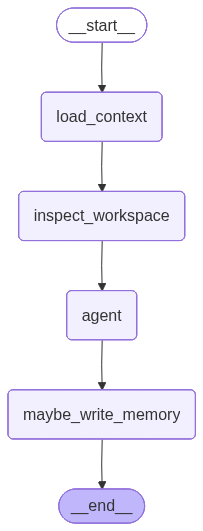

In [12]:
app

## Первый запуск

Сначала зададим агенту вопрос про **механизм demo workspace**, а не про общий project status.

Так первый memory item должен получиться узким и проверяемым: какие файлы контекста агент читает и где хранит working memory.


In [13]:
result = app.invoke(
    {
        'user_query': 'Изучи demo workspace и кратко объясни, какие файлы контекста агент читает перед ответом.'
    }
)

print(result['response'])
print('\nshould_write_memory =', result.get('should_write_memory'))
print('memory_candidate =', result.get('memory_candidate'))


Агент читает контекст из следующих файлов рабочей области: `known_pitfalls.md`, `task_notes.md`, `useful_commands.md`. Эти файлы расположены в директории `workspace_demo` и используются для предоставления дополнительного контекста агенту перед выполнением запросов.

should_write_memory = False
memory_candidate = 


In [14]:
print(read_text(TASK_NOTES) or '[task_notes.md is empty]')


[task_notes.md is empty]


## Второй запуск: агент уже стартует не с нуля

Теперь задаем второй вопрос. На этом шаге граф снова читает `AGENTS.md`, снова читает memory files и подает их модели перед ответом.

Если первый запуск сохранил хороший narrow finding, второй ответ должен сослаться на него без повторного сохранения дубля.


In [15]:
result2 = app.invoke(
    {
        'user_query': 'Напомни, какие устойчивые выводы о состоянии проекта уже были сохранены в памяти.'
    }
)

print(result2['response'])


Пока никаких устойчивых выводов о состоянии проекта в рабочей памяти не сохранено.


## Что здесь произошло

- `load_context` загрузил instructions и текущую память;
- `inspect_workspace` дал модели grounded view на файловую структуру;
- `agent` сформировал ответ на запрос пользователя;
- `maybe_write_memory` сохранил короткий reusable finding для следующего запуска.

Именно это и есть минимальный пример **persistent workspace context**.


## Почему это не то же самое, что `RAG`

Здесь мы не строим retrieval по внешнему корпусу и не ищем ответ в knowledge base.

Вместо этого:
- `AGENTS.md` задает **как работать** в этом проекте;
- memory files помогают помнить **что уже было выяснено**;
- workspace inspection дает модели **актуальную картину локальной среды**.

Это другой слой агентной системы: не knowledge retrieval, а **instruction + persistence + workspace grounding**.


## Failure modes

На что здесь стоит смотреть критически:
- `stale instructions`: `AGENTS.md` устарел и ведет агента не туда;
- `stale memory`: агент опирается на старые findings после изменений в проекте;
- `memory bloat`: память разрастается и перестает быть полезной;
- `conflicting notes`: в memory есть противоречивые выводы;
- `bad auto-learnings`: агент сохранил в память слабый или неверный вывод;
- `absence noise`: агент сохранил слишком общий вывод об отсутствующих артефактах вместо конкретного operational finding.


In [16]:
print('AGENTS.md\n')
print(read_text(AGENTS_PATH))

print('\nCurrent task memory\n')
print(read_text(TASK_NOTES) or '[empty]')


AGENTS.md

# AGENTS.md

## Project
This workspace contains course materials for Промышленная разработка AI-агентов.

## Instructions
- Treat notebooks 01-04 in topic7_rag as the local teaching workspace.
- Focus on repo structure, current notebook state, and reusable operational findings.
- Prefer concise summaries grounded in inspected files.
- Save only narrow, stable findings that will be useful in later runs.
- Do not save broad claims like "everything else needs work" unless the inspected files prove a specific actionable gap.


Current task memory

[empty]


## Exercises: память в ручном LangGraph и Deep Agents

Сначала доработайте ручной LangGraph-вариант, чтобы понять механику памяти. Затем перенесите ту же идею в Deep Agents harness, но **без skills**: нас интересуют только файловый workspace, persistent memory и правила записи в память.

Результат должен быть один: агент читает `AGENTS.md` и `workspace_demo/memory/*.md`, отвечает grounded по workspace context и сохраняет только узкие reusable findings.


In [ ]:
# Exercise scaffold

def route_memory_item(memory_bullet: str) -> str:
    """Верни имя файла памяти, куда логичнее положить запись."""
    raise NotImplementedError


def memory_quality_check(memory_bullet: str) -> bool:
    """Верни True, только если finding достаточно узкий и переиспользуемый."""
    # TODO: отклоняйте слишком общие или быстро протухающие claims.
    # Примеры плохих bullets:
    # - "Остальные элементы проекта требуют доработки"
    # - "В репозитории есть ноутбуки"
    # - "Проект не готов"
    raise NotImplementedError


In [ ]:
# Exercise 2. Соберите Deep Agent harness только для файловой памяти
#
# Подсказка по установке зависимости для этого repo:
#   python -m pip install deepagents
# Для постоянной фиксации добавьте deepagents в requirements.txt и переустановите зависимости.
#
# Ориентир из agent-skills-masterclass: create_deep_agent + backend + MemorySaver.
# Но в этом упражнении НЕ подключайте skills=[...]. Правила памяти задайте в system_prompt.

# TODO 1: импортируйте create_deep_agent, backend и MemorySaver.
# Пример из masterclass использует:
# from deepagents import create_deep_agent
# from deepagents.backends import LocalShellBackend
# from langgraph.checkpoint.memory import MemorySaver
#
# В некоторых версиях deepagents backend может называться иначе.
# Если LocalShellBackend недоступен, проверьте актуальные backends в вашей версии пакета
# и используйте ограниченный filesystem backend для WORKSPACE_DIR.

# TODO 2: создайте backend с root_dir=str(WORKSPACE_DIR).
# Важно: ограничьте агенту рабочую папку demo workspace, а не весь repo.

# TODO 3: создайте deep_agent с:
# - model=llm
# - backend=backend
# - checkpointer=MemorySaver()
# - system_prompt, который требует:
#   * перед ответом читать AGENTS.md;
#   * читать memory/task_notes.md, memory/known_pitfalls.md, memory/useful_commands.md;
#   * писать в memory/task_notes.md только narrow operational findings;
#   * не сохранять broad claims вроде "остальное требует доработки".

# deep_agent = create_deep_agent(...)

# Self-check после реализации:
# print('Deep Agent workspace:', WORKSPACE_DIR)
# deep_agent


In [ ]:
# Exercise 3. Повторите первый запуск через Deep Agent
#
# Цель: получить тот же outcome, что в ручном LangGraph demo, но через built-in filesystem tools Deep Agents:
# - agent сам читает AGENTS.md;
# - agent сам читает memory/*.md;
# - agent при необходимости редактирует memory/task_notes.md;
# - запись в память остается narrow и reusable.

config_deep = {'configurable': {'thread_id': 'workspace-memory-demo'}}

# TODO: вызовите deep_agent.invoke(..., config=config_deep).
# Запрос оставьте похожим на ручной demo:
# "Изучи demo workspace и кратко объясни, какие файлы контекста агент читает перед ответом. Если есть новый узкий operational finding — сохрани его в memory/task_notes.md."

# deep_result = deep_agent.invoke(
#     {'messages': [{'role': 'user', 'content': '...'}]},
#     config=config_deep,
# )
#
# for msg in deep_result['messages']:
#     msg.pretty_print()

# После запуска проверьте файл:
# print(read_text(TASK_NOTES) or '[task_notes.md is empty]')


In [ ]:
# Exercise 4. Сравните ручной LangGraph и Deep Agents для memory use case
#
# Заполните таблицу наблюдений после запуска обеих версий.

comparison_notes = pd.DataFrame([
    {
        'dimension': 'context loading',
        'manual_langgraph': 'явные ноды load_context / inspect_workspace',
        'deep_agents': 'TODO: какие filesystem tools вызвал агент?',
    },
    {
        'dimension': 'memory write control',
        'manual_langgraph': 'maybe_write_memory + guardrail в коде',
        'deep_agents': 'TODO: достаточно ли system_prompt, или нужен отдельный write-memory tool?',
    },
    {
        'dimension': 'persistence',
        'manual_langgraph': 'обычные markdown-файлы на диске',
        'deep_agents': 'TODO: что сохраняется через filesystem backend / checkpointer?',
    },
    {
        'dimension': 'observability',
        'manual_langgraph': 'видна структура графа',
        'deep_agents': 'TODO: что видно в Phoenix trace?',
    },
])

comparison_notes


### Что должно получиться после exercises

Минимальный acceptable result:

1. Ручной LangGraph-вариант умеет route / quality-check для memory item.
2. Deep Agent создан без skills: только model + filesystem backend + checkpointer + memory-oriented system prompt.
3. Deep Agent может ответить, какие файлы контекста он читает перед ответом.
4. Если агент пишет `task_notes.md`, запись узкая и проверяемая, например про механизм demo workspace, а не про общий статус проекта.
5. В сравнительной таблице понятно, что ручной LangGraph полезен для объяснения механики, а Deep Agents — для демонстрации готового harness-а с filesystem и persistence.


## Итоги

В этом ноутбуке появился новый слой агентной системы.

После `RAG` и `GraphRAG` мы добавили:
- `instruction layer` через `AGENTS.md`;
- `working memory layer` через простые files on disk;
- минимальный `LangGraph`, который явно поднимает этот контекст перед LLM-вызовом.

Это естественный мост от retrieval-агентов к workspace- и coding-agents.
